# Seaborn 01 - Seaborn Foundations

> **MLCourse · Data Science Foundations · 04_seaborn**

Welcome to the visualization module! Seaborn is the statistical-graphics
layer of the Python data stack: it takes tidy DataFrames and turns them into
polished, statistically-aware figures with remarkably little code. This
notebook builds your mental model from zero: what seaborn is, how its
two-level API works (the single most important concept in this course), and
how to wield relational plots, distribution plots, categorical plots, and
palettes with confidence.

Everything here runs on seaborn's built-in datasets, so you can follow along
without downloading anything.

### What you'll learn

- The seaborn philosophy: dataset-oriented, statistics-aware defaults that
  look good out of the box - and how seaborn relates to raw matplotlib.
- The **two-level API**: axes-level functions vs figure-level functions,
  and when to reach for each.
- **Relational plots**: `scatterplot`, `lineplot`, and the `relplot`
  dispatcher; semantic mapping with `hue`, `style`, `size`, `markers`.
- How `lineplot` automatically aggregates repeated measurements and draws a
  **bootstrap confidence band**.
- **Distribution plots**: histograms (`histplot`), kernel density estimates
  (`kdeplot`, 1-D and 2-D), empirical CDFs (`ecdfplot`), and rugs.
- **Categorical summaries**: boxplots, violinplots, boxenplots, strip and
  swarm plots - plus aggregate views with `countplot`, `barplot`, and
  `pointplot`.
- Faceting made trivial with the figure-level `catplot`.
- A practical tour of **palettes**: qualitative, sequential, diverging, and
  colorblind-safe practice.

### 1. Why seaborn exists (and how it relates to matplotlib)

Matplotlib is a general-purpose plotting engine: extremely flexible, but you
specify everything - colors, labels, ticks, legends - by hand. Seaborn sits
on top of matplotlib and makes a different trade:

- **Dataset-oriented.** You pass a DataFrame plus column *names*
  (`x="total_bill"`), not arrays. Column names become axis labels and legend
  titles for free.
- **Statistics-aware defaults.** Many seaborn functions do light statistics
  before drawing: `lineplot` averages repeats with confidence intervals,
  `barplot` estimates means with uncertainty, KDEs smooth densities. You get
  honest plots by default.
- **Beautiful out of the box.** Themes, font scales, and perceptually-sane
  color palettes are one function call away.

Crucially, seaborn does **not** replace matplotlib - it drives it. Every
seaborn figure is a real matplotlib `Figure` full of real matplotlib
`Axes`, so anything you learn later about matplotlib fine-tuning still
applies. That interop is the subject of notebook 02.

### Standard setup cell for every notebook in this module.


In [ ]:
# Note: we trigger the Jupyter "%matplotlib inline" magic through its
# Python equivalent so this file stays valid, runnable pure Python.
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821
except NameError:
    # Not running inside Jupyter (e.g. plain script execution) - nothing to do.
    pass

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme()  # apply seaborn's default theme EARLY so every plot inherits it

print("seaborn", sns.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)


def load_dataset(name):
    """Load a built-in seaborn dataset with a friendly offline hint."""
    try:
        return sns.load_dataset(name)
    except Exception as exc:  # network error, proxy, missing file...
        print(f"[offline hint] Could not load '{name}': {exc}")
        print("  Check your internet connection, or download the CSV from")
        print("  https://github.com/mwaskom/seaborn-data and use pd.read_csv.")
        return None


tips = load_dataset("tips")
penguins = load_dataset("penguins")
mpg = load_dataset("mpg")
flights = load_dataset("flights")
titanic = load_dataset("titanic")

for label, df in [("tips", tips), ("penguins", penguins), ("mpg", mpg),
                  ("flights", flights), ("titanic", titanic)]:
    print(f"{label:>9}: {df.shape if df is not None else 'NOT LOADED'}")

tips.head()


> ⚠️ **Common pitfall:** `sns.set_theme()` resets *everything* - style,
context, palette, and any manual `rc` overrides. Call it once near the top
of the notebook, then make targeted adjustments afterwards; calling it in
the middle silently throws away earlier tweaks.

### 2. Themes, styles, and contexts

Seaborn splits "look" into three knobs:

- **Style** controls the background furniture: grid, background color,
  spines. Options: `darkgrid` (default), `whitegrid`, `dark`, `white`,
  `ticks`. Grids help read values (`*grid`); clean styles help publication
  figures (`white`, `ticks`).
- **Context** scales fonts, line widths, and marker sizes for the output
  medium: `paper` < `notebook` (default) < `talk` < `poster`. Same plot,
  bigger presence.
- **Palette** controls colors (section 14).

`sns.set_theme()` sets all three at once. For temporary changes, use
`sns.axes_style(...)` / `sns.plotting_context(...)` as context managers -
perfect for side-by-side galleries like the ones below.

### Gallery of the five built-in styles. We draw the same small histogram on


In [ ]:
# every panel inside a temporary axes_style so the change is local to the loop.
styles = ["darkgrid", "whitegrid", "dark", "white", "ticks"]
rng = np.random.default_rng(42)
sample = rng.normal(loc=0.0, scale=1.0, size=400)

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, style_name in zip(axes.flat, styles):
    with sns.axes_style(style_name):
        sns.histplot(x=sample, bins=25, ax=ax)
    ax.set_title(style_name)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes.flat[-1].set_visible(False)  # 5 styles, 6 slots: hide the spare panel
plt.tight_layout()
plt.show()


### Contexts scale typography for the destination medium. Same line, four sizes.


In [ ]:
contexts = ["paper", "notebook", "talk", "poster"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
x_line = np.linspace(0, 10, 100)
for ax, ctx in zip(axes.flat, contexts):
    with sns.plotting_context(ctx):
        ax.plot(x_line, np.sin(x_line))
        ax.set_title(ctx)
plt.tight_layout()
plt.show()


> 💡 **Pro tip:** the minimal look many journals want is
`sns.set_theme(style="ticks")` plus `sns.despine()` after plotting - no top
or right spine, ticks only where data lives.

### 3. The two-level API: axes-level vs figure-level functions

This is the concept that unlocks everything else in seaborn, so read it
twice. Every seaborn plotting function belongs to exactly one of two levels:

| Level | Returns | Accepts `ax=`? | Faceting | Examples |
|---|---|---|---|---|
| **Axes-level** | a single matplotlib `Axes` | Yes - drops into any subplot grid | No (one panel per call) | `scatterplot`, `lineplot`, `histplot`, `kdeplot`, `boxplot`, `violinplot`, `barplot`, `countplot`, `regplot`, `heatmap` |
| **Figure-level** | a seaborn `FacetGrid` (own Figure) | **No** - always makes a new figure | Yes - native `col=`, `row=` | `relplot`, `displot`, `catplot`, `lmplot`, `jointplot`, `pairplot` |

Rules of thumb:

- Figure-level functions are *dispatchers*: `relplot(kind="scatter")` just
  calls `scatterplot` under the hood, but adds faceting and legend management.
- Use **axes-level** when composing custom layouts (`plt.subplots` grids,
  dashboards) or layering multiple plot types on shared axes.
- Use **figure-level** when exploring conditional relationships across
  facets - it is dramatically less code.
- Because figure-level calls create their own window, assign them to a
  variable (`g = ...`) so you can keep tweaking via `g.figure`.

### Proof of the two return types.


In [ ]:
ax_scatter = sns.scatterplot(data=tips, x="total_bill", y="tip")
print("axes-level returns :", type(ax_scatter).__name__)

g_rel = sns.relplot(data=tips, x="total_bill", y="tip", col="time", height=3.2)
print("figure-level returns:", type(g_rel).__name__,
      "(wrapping a", type(g_rel.figure).__name__ + ")")
plt.close("all")  # tidy up the demo windows


### Axes-level functions compose into arbitrary matplotlib layouts via ax=.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=tips, x="day", y="total_bill", ax=axes[0])
axes[0].set_title("boxplot on a chosen Axes")
sns.violinplot(data=tips, x="day", y="total_bill", ax=axes[1])
axes[1].set_title("violinplot beside it")
plt.tight_layout()
plt.show()


> 💡 **Pro tip:** figure-level functions accept `height` and `aspect`
(width = height × aspect) instead of `figsize`. Each facet keeps those
proportions however many columns you request.

### 4. Semantic mapping: hue, style, size, markers

Seaborn lets extra DataFrame columns drive visual channels - these are
**semantics**:

- `hue=` → color. Numeric hue gets a continuous gradient automatically;
  categorical hue cycles a discrete palette.
- `style=` → dash patterns (lines) or marker shapes (points).
- `size=` → area (points/lines), scaled via `sizes=(min, max)`.
- `markers=True` / `dashes=False` fine-tune line-and-marker combos.

Each semantic is one more dimension of your data encoded visually. Two or
three semantics read comfortably; more becomes spaghetti.

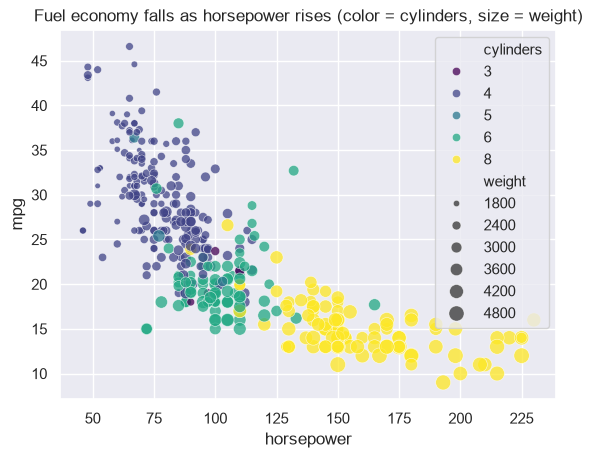

In [6]:
# hue + size on a scatter: cylinder count (numeric -> sequential ramp),
# weight mapped to point area. One call, three variables compared.
sns.scatterplot(
    data=mpg, x="horsepower", y="mpg",
    hue="cylinders", palette="viridis",
    size="weight", sizes=(15, 130),
    alpha=0.75,
)
plt.title("Fuel economy falls as horsepower rises (color = cylinders, size = weight)")
plt.show()

### Lines with hue AND style: origin both colors the trend and changes the


In [ ]:
# marker, so the chart survives grayscale printing too.
yearly = (
    mpg.groupby(["model_year", "origin"], as_index=False)["mpg"]
    .mean()
)
ax = sns.lineplot(
    data=yearly, x="model_year", y="mpg",
    hue="origin", style="origin",
    markers=True, dashes=False,
)
ax.set_title("Average mpg by model year and origin")
ax.set_xlabel("model year")
plt.show()


> ⚠️ **Common pitfall:** stacking four semantics on one panel (`hue`,
`style`, `size`, *and* facets) produces charts nobody can decode. If you
need a fourth dimension, facet instead - section 13 shows how.

### 5. Line plots that think: aggregation and bootstrap confidence bands

Feed `lineplot` several y-values per x and it quietly does statistics for
you: it draws the **mean** at each x plus a **95% confidence interval**
band computed by *bootstrapping* - resampling the observed values with
replacement many times, re-computing the mean each time, and taking the
2.5th/97.5th percentiles of those means. The band answers: "how sure are we
about this average?"

Control it with the `errorbar` parameter:

- `errorbar=("ci", 95)` - bootstrap CI (the default).
- `errorbar=("sd", 1)` / `("sd", 2)` - ± standard deviations (data spread).
- `errorbar=("pi", 90)` - percentile interval of the raw data.
- `errorbar=None` - turn off entirely (fast).

`err_style="band"` (default) or `"bars"` chooses the look; `n_boot`
trades accuracy for speed.

### Synthetic example: 60 days × 40 sensors measuring a drifting signal.


In [ ]:
# Long-form data with repeats per x is exactly what triggers aggregation.
sensor_rng = np.random.default_rng(42)
days = np.repeat(np.arange(60), 40)
signal = 10 + 0.08 * days + sensor_rng.normal(0, 2.0, days.size)
readings = pd.DataFrame({"day": days, "value": signal})

ax = sns.lineplot(data=readings, x="day", y="value")
ax.set_title("Mean over 40 sensors per day, shaded = 95% bootstrap CI")
plt.show()


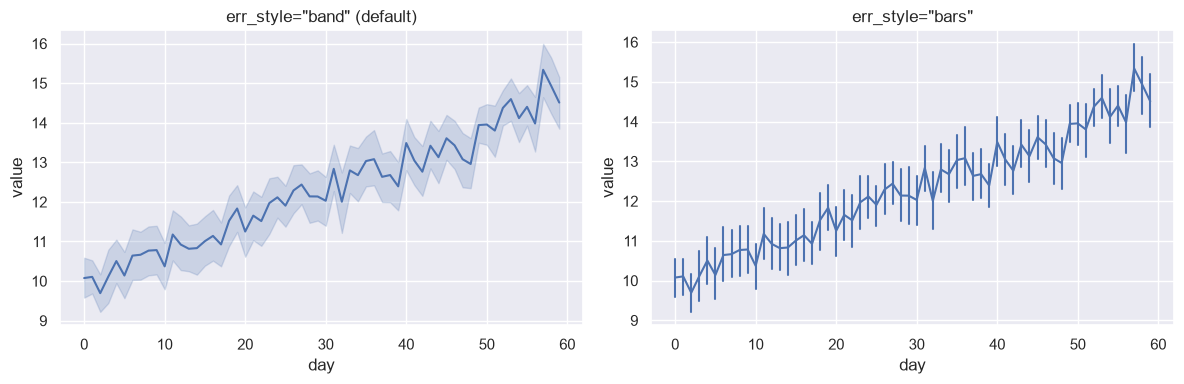

In [9]:
# Band vs bars, same data. Both encode the SAME statistic - only geometry differs.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=readings, x="day", y="value", err_style="band", ax=axes[0])
axes[0].set_title('err_style="band" (default)')
sns.lineplot(data=readings, x="day", y="value", err_style="bars", ax=axes[1])
axes[1].set_title('err_style="bars"')
plt.tight_layout()
plt.show()

### Real data: flights has one observation per (year, month), so first


In [ ]:
# aggregate to yearly totals, then plot. Drawing x=year with hue=month would
# stack 12 tangled lines on one panel - reserve that for heatmaps/facets.
flights_yearly = flights.groupby("year", as_index=False)["passengers"].sum()
ax = sns.lineplot(data=flights_yearly, x="year", y="passengers", marker="o")
ax.set_title("Total airline passengers per year (1949-1960)")
plt.show()


> ⚠️ **Common pitfall:** if exactly one observation exists per x value, no
band appears - there is nothing to aggregate. That is seaborn being honest,
not a bug. Aggregate upstream or switch to a plain line.

> 💡 **Pro tip:** on datasets with thousands of points per group set
`n_boot=200` (or `errorbar=None`) while exploring; restore defaults for the
final figure.

### 6. Histograms done right: histplot

The histogram chops the range into bins and counts. Its knobs matter:

- `bins=` an integer, or `binwidth=`/`binrange=` for explicit control.
- `stat=` what the bar height means: `"count"`, `"density"`
  (area sums to 1), `"probability"` (fraction of observations).
- `kde=True` overlays a smooth density curve on the bars.
- With `hue=`, `multiple=` decides how groups coexist: `"layer"`
  (translucent overlap), `"stack"`, `"fill"` (proportions to 100%), or
  `"dodge"` (side-by-side bars).

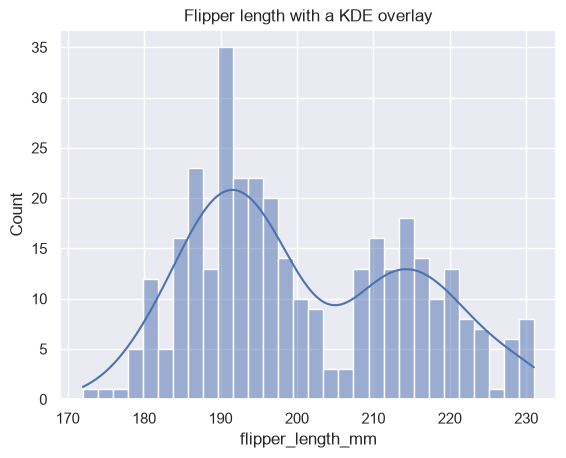

In [11]:
sns.histplot(data=penguins, x="flipper_length_mm", bins=30, kde=True)
plt.title("Flipper length with a KDE overlay")
plt.show()

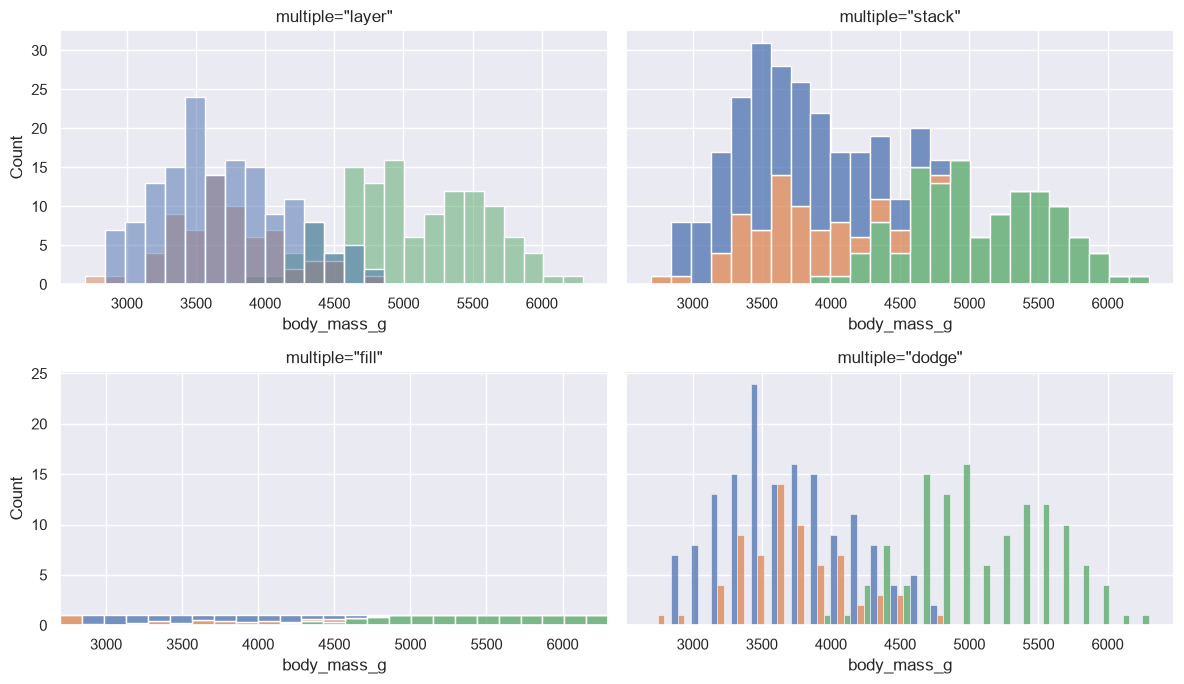

In [12]:
# The four ways hue groups can share a histogram panel.
multiples = ["layer", "stack", "fill", "dodge"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey="row")
for ax, mode in zip(axes.flat, multiples):
    sns.histplot(
        data=penguins, x="body_mass_g", hue="species",
        multiple=mode, bins=25, ax=ax, legend=False,
    )
    ax.set_title(f'multiple="{mode}"')
plt.tight_layout()
plt.show()

> ⚠️ **Common pitfall:** bin edges change the story. A histogram with
`binwidth=50` can hide a dip that `binwidth=500` invents. Always try two or
three bin widths before trusting a shape.

> 💡 **Pro tip:** comparing group *shapes* fairly? Use
`stat="density", common_norm=False` so each species' curve integrates to 1
independently instead of shrinking by group size.

### 7. Kernel density estimates: kdeplot

A KDE replaces each data point with a small smooth bump and sums the bumps -
a continuous version of the histogram with no arbitrary bin edges. Key knobs:

- `bw_adjust=` multiplies the bump width: `<1` follows the data closely
  (wiggly), `>1` smooths aggressively (may blur real features).
- `cut=` how far past the min/max the curve may extend (default 3 bandwidths;
  `cut=0` clamps to observed range - right choice for bounded quantities
  like weights or prices that cannot go negative).
- Two numeric axes give **2-D contours**, like a topographic map of density.

### Bandwidth sweep on one species so the effect is unmistakable.


In [ ]:
adelie = penguins[penguins["species"] == "Adelie"]
bw_values = [0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, bw in zip(axes.flat, bw_values):
    sns.kdeplot(data=adelie, x="body_mass_g", bw_adjust=bw, fill=True, ax=ax)
    ax.set_title(f"bw_adjust={bw}")
plt.tight_layout()
plt.show()


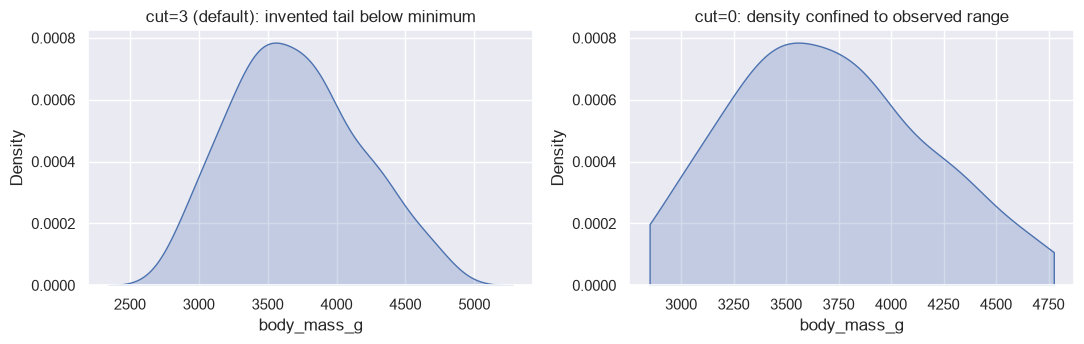

In [14]:
# cut=0 stops the density from leaking below zero mass.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.kdeplot(data=adelie, x="body_mass_g", fill=True, ax=axes[0])
axes[0].set_title("cut=3 (default): invented tail below minimum")
sns.kdeplot(data=adelie, x="body_mass_g", fill=True, cut=0, ax=axes[1])
axes[1].set_title("cut=0: density confined to observed range")
plt.tight_layout()
plt.show()

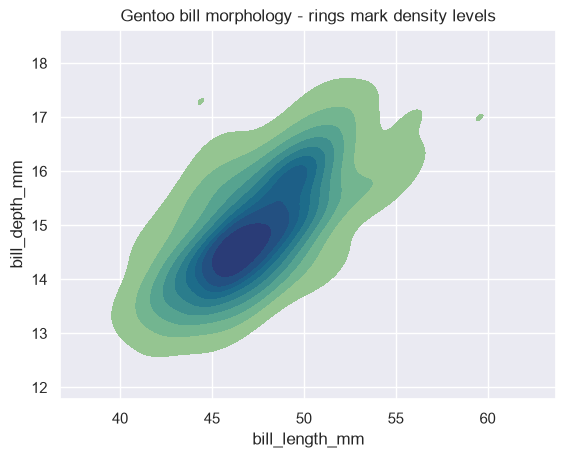

In [15]:
# 2-D KDE: filled contour rings over bill dimensions of Gentoo penguins.
gentoo = penguins[penguins["species"] == "Gentoo"]
ax = sns.kdeplot(
    data=gentoo, x="bill_length_mm", y="bill_depth_mm",
    fill=True, cmap="crest", levels=10, thresh=0.05,
)
ax.set_title("Gentoo bill morphology - rings mark density levels")
plt.show()

> ⚠️ **Common pitfall:** a KDE will happily paint density where no data can
exist (negative prices, zero masses). Reach for `cut=0` whenever the
quantity is physically bounded.

### 8. ECDF and rugs: honesty-first distributions

The **empirical cumulative distribution function** plots, for every value x,
the fraction of observations ≤ x. Why it often beats a histogram:

- **No tuning parameters** - no bins, no bandwidth, nothing to fudge.
- Quantiles are read off directly: find 0.5 on y, drop to x → the median.
- Multiple groups overlay cleanly and are easy to compare at any threshold.

A `rugplot` adds one small tick per observation along an axis - a 1-D
scatter that shows exactly where the raw data sits.

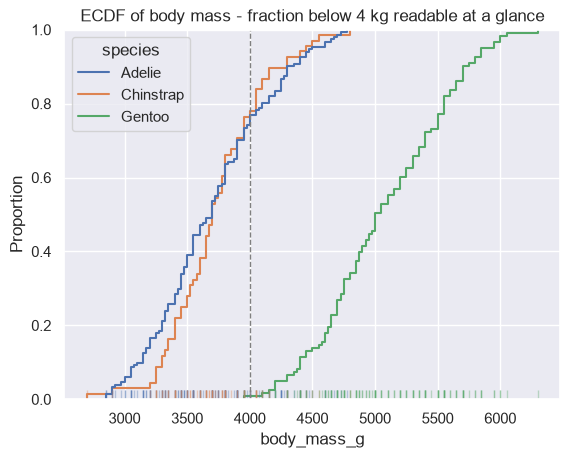

species
Adelie       0.74
Chinstrap    0.76
Gentoo       0.01
Name: under, dtype: float64


In [16]:
ax = sns.ecdfplot(data=penguins, x="body_mass_g", hue="species")
sns.rugplot(data=penguins, x="body_mass_g", hue="species", ax=ax, alpha=0.35)
ax.axvline(4000, color="gray", ls="--", lw=1)
ax.set_title("ECDF of body mass - fraction below 4 kg readable at a glance")
plt.show()

below_4k = penguins.assign(under=lambda d: d["body_mass_g"] < 4000)
print(below_4k.groupby("species")["under"].mean().round(2))

> 💡 **Pro tip:** any question phrased "*what fraction of X is below Y*" -
SLAs, thresholds, passing grades - is answered instantly by an ECDF and
awkwardly by a histogram.

### 9. Boxplots: the five-number summary, drawn

Anatomy recap (worth memorizing):

- **Box** spans the IQR (25th-75th percentiles); its inner line is the
  **median**.
- **Whiskers** extend to the most extreme points within 1.5 × IQR of the box
  edges (change with `whis=`; e.g. `whis=(5, 95)` uses percentiles).
- **Fliers** (diamond dots) fall outside the whisker fence - candidate
  outliers, not errors.

Adding `hue=` dodges boxes side-by-side per group.

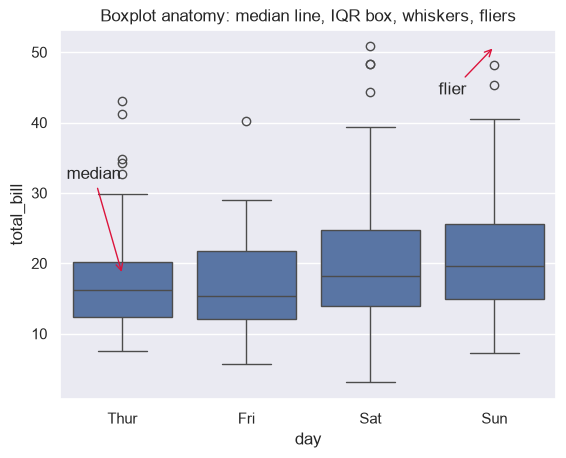

In [17]:
ax = sns.boxplot(data=tips, x="day", y="total_bill")
ax.set_title("Boxplot anatomy: median line, IQR box, whiskers, fliers")
# Point at the parts (coordinates approximate, purely illustrative).
ax.annotate("median", xy=(0, 18.4), xytext=(-0.45, 32),
            arrowprops=dict(arrowstyle="->", color="crimson"))
ax.annotate("flier", xy=(3, 50.8), xytext=(2.55, 44),
            arrowprops=dict(arrowstyle="->", color="crimson"))
plt.show()

### Default 1.5*IQR whiskers vs percentile whiskers.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.boxplot(data=tips, x="day", y="tip", whis=1.5, ax=axes[0])
axes[0].set_title("whis=1.5 (classic Tukey fence)")
sns.boxplot(data=tips, x="day", y="tip", whis=(5, 95), ax=axes[1])
axes[1].set_title("whis=(5, 95): whiskers at percentiles")
plt.tight_layout()
plt.show()


> ⚠️ **Common pitfall:** whisker rules differ across software (Excel,
matplotlib, seaborn all vary subtly). When publishing, state your whisker
definition in the caption.

### 10. Violin and boxen: richer box summaries

A **violinplot** mirrors a KDE around the category axis: wide bulges are
dense regions, narrow necks are sparse ones. Useful options:

- `inner=` what sits inside: `"quart"` (quartile lines), `"box"`
  (mini-boxplot), `"stick"`, `"point"`, or `None`.
- `split=True` with a binary `hue` paints *both halves* - one group per
  side - halving the ink of a dodged pair.
- `density_norm=` (newer name for the older `scale=`) normalizes violin
  areas (`"area"`, `"count"`, `"width"`).

For very large samples, **boxenplot** (letter-value plot) draws nested boxes
covering progressively smaller tail fractions - more quantile detail than a
box, cheaper than a swarm.

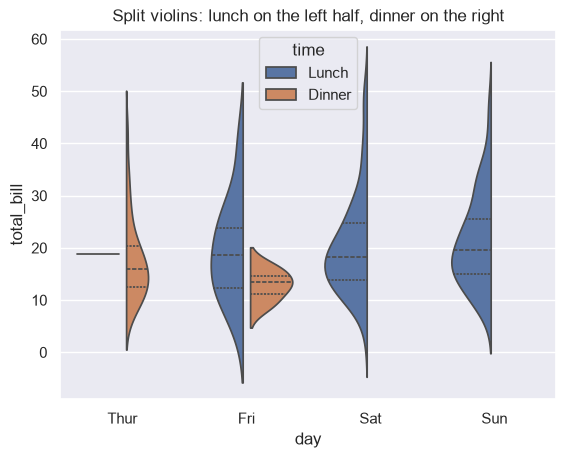

In [19]:
ax = sns.violinplot(
    data=tips, x="day", y="total_bill",
    hue="time", split=True, inner="quart", gap=0.15,
)
ax.set_title("Split violins: lunch on the left half, dinner on the right")
plt.show()

### Diamonds is ~54k rows: sample deterministically for snappy iteration.


In [ ]:
diamonds = load_dataset("diamonds")
if diamonds is not None:
    dia_small = diamonds.sample(5000, random_state=42)
    ax = sns.boxenplot(data=dia_small, x="cut", y="carat")
    ax.set_title("Boxenplot: nested boxes reveal tail structure for large n")
else:
    print("Skipping boxen demo - dataset unavailable.")
plt.show()


> 💡 **Pro tip:** violins imply smoothing; with fewer than ~50 observations
per group they can suggest shapes that are not really there. Small n → use
a boxplot or strip/swarm instead.

### 11. Strip and swarm: showing every observation

Aggregates hide individual points; sometimes the points ARE the message.

- **stripplot** scatters points with random horizontal **jitter**
  (`jitter=0.25`) so coincident values separate visually.
- **swarmplot** uses a repulsion algorithm so points never overlap - a
  mini-distribution emerges from the outline itself. Cost: much slower on
  big data (roughly quadratic in points per category).

The classic power combo: a pale violin behind dark swarming points.

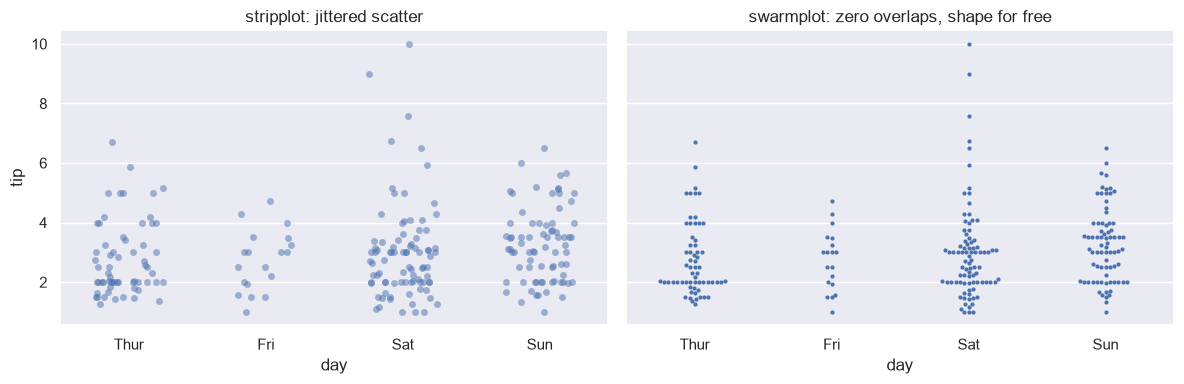

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.stripplot(data=tips, x="day", y="tip", jitter=0.25, alpha=0.5, ax=axes[0])
axes[0].set_title("stripplot: jittered scatter")
sns.swarmplot(data=tips, x="day", y="tip", size=3, ax=axes[1])
axes[1].set_title("swarmplot: zero overlaps, shape for free")
plt.tight_layout()
plt.show()

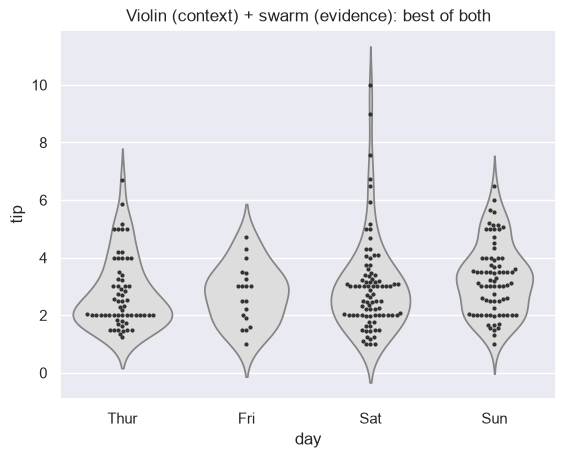

In [22]:
ax = sns.violinplot(data=tips, x="day", y="tip", inner=None, color="#dddddd")
sns.swarmplot(data=tips, x="day", y="tip", size=3, color="#333333", ax=ax)
ax.set_title("Violin (context) + swarm (evidence): best of both")
plt.show()

> ⚠️ **Common pitfall:** `swarmplot` crawls beyond a few thousand points per
category and may fail to place them all. Subsample first, or fall back to
`stripplot`.

### 12. Aggregate views: countplot, barplot, pointplot

Three functions summarize categories, each answering a different question:

- **countplot** - *how many rows?* Pure frequencies; needs only `x`.
- **barplot** - *what is the average of some measure?* Aggregates `y` per
  group (`estimator=np.mean` by default) and draws a **bootstrap CI** as the
  error bar. Swap with `estimator=np.median`; control the bar with
  `errorbar=("sd", 1)` etc. (The legacy `ci=95` argument maps to
  `errorbar=("ci", 95)`.)
- **pointplot** - the same estimate as dots connected within `hue` levels;
  slopes make **interactions** obvious (non-parallel lines = effect depends
  on the other factor).

### Frequency ordering trick: sort classes by row count using value_counts().index.


In [ ]:
class_order = titanic["class"].value_counts().index.tolist()
ax = sns.countplot(data=titanic, x="class", hue="sex", order=class_order)
ax.set_title("Titanic passengers per class (bars ordered by frequency)")
plt.show()


### Mean vs median estimator; note the errorbar meaning changes with it.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.barplot(data=tips, x="day", y="tip", errorbar=("ci", 95), ax=axes[0])
axes[0].set_title("estimator=mean (default), 95% bootstrap CI")
sns.barplot(
    data=tips, x="day", y="tip",
    estimator=np.median, errorbar=("sd", 1), ax=axes[1],
)
axes[1].set_title("estimator=median, ±1 SD of the data")
plt.tight_layout()
plt.show()


### Interaction view: does the day-of-week effect on tipping differ between


In [ ]:
# smokers and non-smokers? Parallel lines would mean "no interaction".
ax = sns.pointplot(data=tips, x="day", y="tip", hue="smoker", dodge=0.35)
ax.set_title("Pointplot interaction: day × smoker (non-parallel lines)")
plt.show()


> ⚠️ **Common pitfall:** barplot error bars are the uncertainty **of the
mean** (a bootstrap CI), *not* the spread of individual customers. Say which
one you drew, or readers will misread the chart.

> 💡 **Pro tip:** seaborn starts bar charts at zero by default - keep it
that way; truncated bars exaggerate differences.

### 13. catplot: faceting made trivial

`catplot` is the figure-level hub for every categorical plot. Pass
`kind="bar"/"box"/"violin"/"strip"/"swarm"/"point"/"count"` plus optional
`col=`/`row=` to build a facet grid in one call. It returns a `FacetGrid`,
so all grid tweaks (`g.set_axis_labels`, `g.figure.suptitle`, ...) apply.

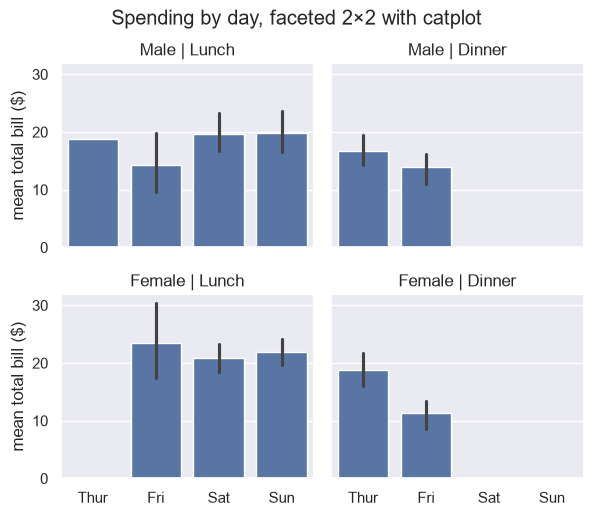

In [26]:
g = sns.catplot(
    data=tips, kind="bar",
    x="day", y="total_bill", col="time", row="sex",
    height=2.6, aspect=1.15, errorbar=("ci", 95),
)
g.set_axis_labels("", "mean total bill ($)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.figure.suptitle("Spending by day, faceted 2×2 with catplot", y=1.03)
plt.show()

> ⚠️ **Common pitfall:** figure-level functions ignore `ax=` and open a new
figure on every call. Assign the result and reuse `g`; close stale windows
with `plt.close("all")` during exploration.

> 💡 **Pro tip:** swapping `kind="bar"` for `kind="box"` re-renders the whole
facet layout instantly - cheap way to test which encoding tells the story.

### 14. Palettes: speaking fluent color

Choose palettes by *what the color means*:

| Data type | Palette family | Good choices |
|---|---|---|
| Categories (no order) | Qualitative | `deep` (default), `muted`, `colorblind`, `Set2`, `tab10` |
| Ordered magnitude | Sequential | `crest`, `viridis`, `rocket`, `mako`, `flare`, `Blues` |
| Deviation around a midpoint | Diverging | `coolwarm`, `RdBu_r`, `vlag`, `Spectral` |

Apply per call with `palette="..."`, or globally with `sns.set_palette(...)`.
Add `as_cmap=True` wherever a colormap object is expected (heatmaps, 2-D
KDEs). Prefer `"colorblind"` for anything public - roughly 1 in 12 men has
some color-vision deficiency.

### Qualitative previews.


In [ ]:
for name in ["deep", "muted", "colorblind", "Set2"]:
    sns.palplot(sns.color_palette(name))
    plt.title(name)
plt.show()


### Sequential ramps shown as gradients.


In [ ]:
gradient = np.linspace(0, 1, 256).reshape(1, -1)
fig, axes = plt.subplots(4, 1, figsize=(6, 4.5))
for ax, name in zip(axes.flat, ["crest", "viridis", "rocket", "mako"]):
    ax.imshow(gradient, aspect="auto", cmap=sns.color_palette(name, as_cmap=True))
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(name, rotation=0, ha="right", va="center")
plt.tight_layout()
plt.show()


### Diverging palettes need a MEANINGFUL center - here a synthetic correlation


In [ ]:
# matrix centered at 0 (positive = warm, negative = cool).
corr_rng = np.random.default_rng(7)
base = corr_rng.normal(size=(80, 5))
synth_corr = np.corrcoef(base, rowvar=False)
labels = ["A", "B", "C", "D", "E"]
sns.heatmap(
    pd.DataFrame(synth_corr, index=labels, columns=labels),
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f",
)
plt.title("Diverging palette centered at zero")
plt.show()


### Global vs per-call palettes.


In [ ]:
sns.set_palette("colorblind")          # global from here on
sns.barplot(data=tips, x="day", y="tip")
plt.title("Global palette switched to 'colorblind'")
plt.show()

sns.set_palette("deep")                # restore the default
ax = sns.barplot(data=tips, x="day", y="tip", palette="flare", hue="day", legend=False)
ax.set_title("Per-call override with palette='flare'")
plt.show()


> ⚠️ **Common pitfall:** rainbow-style maps (jet and friends) distort
perception with fake visual boundaries, and red/green pairs exclude
colorblind readers. Stick to the families above.

### Summary & key takeaways

- Seaborn = **dataset-oriented + statistics-aware + beautiful defaults**,
  driving matplotlib under the hood.
- Memorize the **two-level API**: axes-level functions take `ax=` and compose
  into custom layouts; figure-level functions own their figure and provide
  `col=`/`row=` faceting.
- `lineplot` aggregates repeats into means with **bootstrap CIs**
  (`errorbar=`, `err_style=`, `n_boot=`).
- Distributions: tune histograms carefully (`bins`, `stat`, `multiple`),
  mind KDE bandwidth and `cut=0` for bounded data, prefer ECDFs for
  threshold questions.
- Categorical toolbox: box (five-number), violin (density), boxen (large-n
  quantiles), strip/swarm (raw evidence), count/bar/point (aggregates with
  honest uncertainty).
- `catplot` wraps all of it with effortless faceting.
- Pick palettes by meaning - qualitative, sequential, diverging - and make
  `"colorblind"` your public-facing default.

Next up: **02_seaborn_advanced** - regression plots, heatmaps & clustering,
joint/pair grids, a FacetGrid masterclass, theme fine-tuning, matplotlib
interop, and saving publication-ready figures.